# 1.1 多項式曲線フィッティング (Polynomial Curve Fitting)

機械学習における最も基本的かつ本質的な回帰問題として、BishopのPRML第1章1.1節で導入されるのが**多項式曲線フィッティング**です。
本ノートブックでは、単純な回帰問題を通じて、以下の機械学習の最重要概念をスクラッチから数学的に導出し、Pythonコードで完全再現・検証します：

1. **二乗和誤差関数の数学的定式化**と正規方程式（Normal Equations）の解析解の導出
2. **モデル次数 $M$ による表現力と過学習（Overfitting）の観察**（PRML Figure 1.2, Figure 1.4）
3. **二乗平均平方根誤差（RMS Error, $E_{\text{RMS}}$）による汎化性能の定量的評価**（PRML Figure 1.5）
4. **過学習に伴う重み係数の激しい発散現象**（PRML Table 1.1, Figure 1.6）
5. **データサンプルサイズ $N$ が過学習を緩和するメカニズム**（PRML Figure 1.7）
6. **正則化（Ridge 回帰 / 重み減衰）による過学習の抑制**（PRML Figure 1.8, Figure 1.9）
7. **L2 正則化（Ridge）と L1 正則化（Lasso）の幾何学的比較とスパース性**

## 1.1.1 理論的定式化と正規方程式の導出

### 1. 問題設定
観測データとして、入力変数の訓練セット $\mathbf{x} = (x_1, \ldots, x_N)^T$ と、対応する目標値 $\mathbf{t} = (t_1, \ldots, t_N)^T$ が与えられます。
真の関数関係は未知ですが、ここでは目標変数が次のように生成されたとします：
$$
t_n = \sin(2\pi x_n) + \epsilon_n, \quad \epsilon_n \sim \mathcal{N}(0, \sigma^2)
$$
我々の目的は、新たな入力 $x$ に対して目標値 $t$ を高精度に予測すること（**汎化, Generalization**）です。

### 2. 多項式モデル
入力 $x$ に対する予測関数として、$M$ 次多項式を用います：
$$
y(x, \mathbf{w}) = w_0 + w_1 x + w_2 x^2 + \cdots + w_M x^M = \sum_{j=0}^M w_j x^j = \mathbf{w}^T \boldsymbol{\phi}(x)
$$
ここで $\mathbf{w} = (w_0, w_1, \ldots, w_M)^T$ は多項式の重みベクトル、$\boldsymbol{\phi}(x) = (1, x, x^2, \ldots, x^M)^T$ は多項式基底ベクトルです。このモデルは $x$ については非線形ですが、係数 $\mathbf{w}$ については線形であるため、**線形モデル（Linear Model）**の一種に分類されます。

### 3. 誤差関数（二乗和誤差）
モデルのパラメータ $\mathbf{w}$ を決定するため、予測値 $y(x_n, \mathbf{w})$ と目標値 $t_n$ の差の二乗和誤差関数を定義します（PRML 式 1.2）：
$$
E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \{ y(x_n, \mathbf{w}) - t_n \}^2
$$
係数 $1/2$ は微分したときに 2 を相殺するための便宜的な定数です。

### 4. 解析解（正規方程式）の導出
$E(\mathbf{w})$ を各重み $w_i$ ($i = 0, \ldots, M$) に関して偏微分し、0 と置きます：
$$
\frac{\partial E(\mathbf{w})}{\partial w_i} = \sum_{n=1}^N \{ y(x_n, \mathbf{w}) - t_n \} \frac{\partial y(x_n, \mathbf{w})}{\partial w_i} = 0
$$
$\frac{\partial y(x_n, \mathbf{w})}{\partial w_i} = x_n^i$ であるから、
$$
\sum_{n=1}^N \left( \sum_{j=0}^M w_j x_n^j - t_n \right) x_n^i = 0 \implies \sum_{j=0}^M \left( \sum_{n=1}^N x_n^{i+j} \right) w_j = \sum_{n=1}^N x_n^i t_n
$$
これを行列・ベクトル形式で表すと、以下の**正規方程式（Normal Equations）**が得られます（PRML 式 1.4）：
$$
\mathbf{A} \mathbf{w} = \mathbf{T}
$$
ここで、
$$
A_{ij} = \sum_{n=1}^N x_n^{i+j}, \quad T_i = \sum_{n=1}^N x_n^i t_n \quad (i, j \in \{0, \ldots, M\})
$$
計画行列（Design Matrix）$\boldsymbol{\Phi} \in \mathbb{R}^{N \times (M+1)}$ を
$$
\boldsymbol{\Phi} = \begin{pmatrix} 1 & x_1 & x_1^2 & \cdots & x_1^M \\ 1 & x_2 & x_2^2 & \cdots & x_2^M \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_N & x_N^2 & \cdots & x_N^M \end{pmatrix}
$$
と定義すれば、$\mathbf{A} = \boldsymbol{\Phi}^T \boldsymbol{\Phi}$、$\mathbf{T} = \boldsymbol{\Phi}^T \mathbf{t}$ と書けるため、最適解 $\mathbf{w}^*$ は：
$$
\mathbf{w}^* = (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \mathbf{t}
$$
として厳密に一意に求まります。

Plot saved to: result/fig1_2_synthetic_data.png


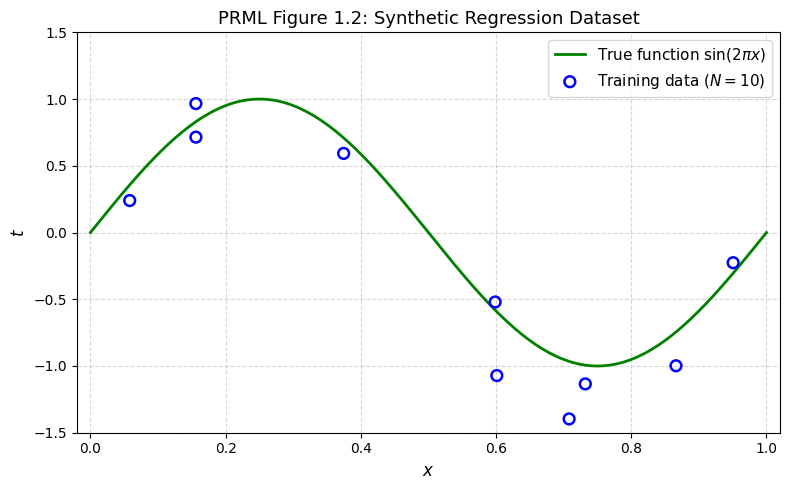

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# 乱数シード固定
np.random.seed(42)

# 1. 真の生成関数
def true_function(x):
    return np.sin(2 * np.pi * x)

# 2. データ生成関数
def generate_synthetic_data(n_samples=10, noise_std=0.25):
    x = np.sort(np.random.uniform(0.0, 1.0, n_samples))
    noise = np.random.normal(0.0, noise_std, n_samples)
    t = true_function(x) + noise
    return x, t

# 訓練データ (N=10) とテストデータ (N=100) の生成
N_train = 10
x_train, t_train = generate_synthetic_data(N_train, noise_std=0.25)
x_test, t_test = generate_synthetic_data(100, noise_std=0.25)

# 3. 多項式計画行列 Phi の構築
def build_design_matrix(x, degree):
    # Phi: shape (N, M + 1), Phi[n, j] = x_n^j
    return np.vander(x, degree + 1, increasing=True)

# 4. 正規方程式のスクラッチ解法 (解析解)
def fit_polynomial_least_squares(x, t, degree, lambda_reg=0.0):
    Phi = build_design_matrix(x, degree)
    # (Phi^T Phi + lambda I) w = Phi^T t
    A = Phi.T @ Phi
    if lambda_reg > 0.0:
        A += lambda_reg * np.eye(degree + 1)
    T = Phi.T @ t
    w_star = np.linalg.solve(A, T)
    return w_star

# 5. 二乗平均平方根誤差 (RMS Error)
def compute_rms_error(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

# PRML Figure 1.2: 合成データセットの可視化
fig, ax = plt.subplots(figsize=(8, 5))
x_dense = np.linspace(0, 1, 200)
ax.plot(x_dense, true_function(x_dense), 'g-', lw=2.0, label='True function $\\sin(2\\pi x)$')
ax.scatter(x_train, t_train, facecolors='none', edgecolors='b', s=60, lw=1.8, zorder=5, label=f'Training data ($N={N_train}$)')
ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('$t$', fontsize=12)
ax.set_title('PRML Figure 1.2: Synthetic Regression Dataset', fontsize=13)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-1.5, 1.5)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
save_plot(fig, 'result', 'fig1_2_synthetic_data.png')
plt.show()

## 1.1.2 多項式の次数 $M$ によるフィッティング曲線の変化 (PRML Figure 1.4)

多項式の次数 $M$ を変化させることで、モデルの表現力とフィッティング性能がどのように変化するかを観察します：
- **$M = 0$**: 定数関数 $y(x) = w_0$。モデルが単純すぎてデータを表現できず、**未学習（Underfitting / High Bias）**。
- **$M = 1$**: 一次関数 $y(x) = w_0 + w_1 x$。依然として直線であり、$\sin$ 曲線の曲率を捉えきれない。
- **$M = 3$**: 3次関数。真の関数 $\sin(2\pi x)$ を滑らかに捉え、最も良好な汎化性能を示す。
- **$M = 9$**: 9次多項式。自由度が $M+1=10$ 個あり、10個の訓練データ点をすべて正確に通る（$E(\mathbf{w}) = 0$）。しかし、データ点の間で極端に激しく振動し、真の関数から大きく乖離する**過学習（Overfitting / High Variance）**が発生する。

Plot saved to: result/fig1_4_polynomial_fits.png


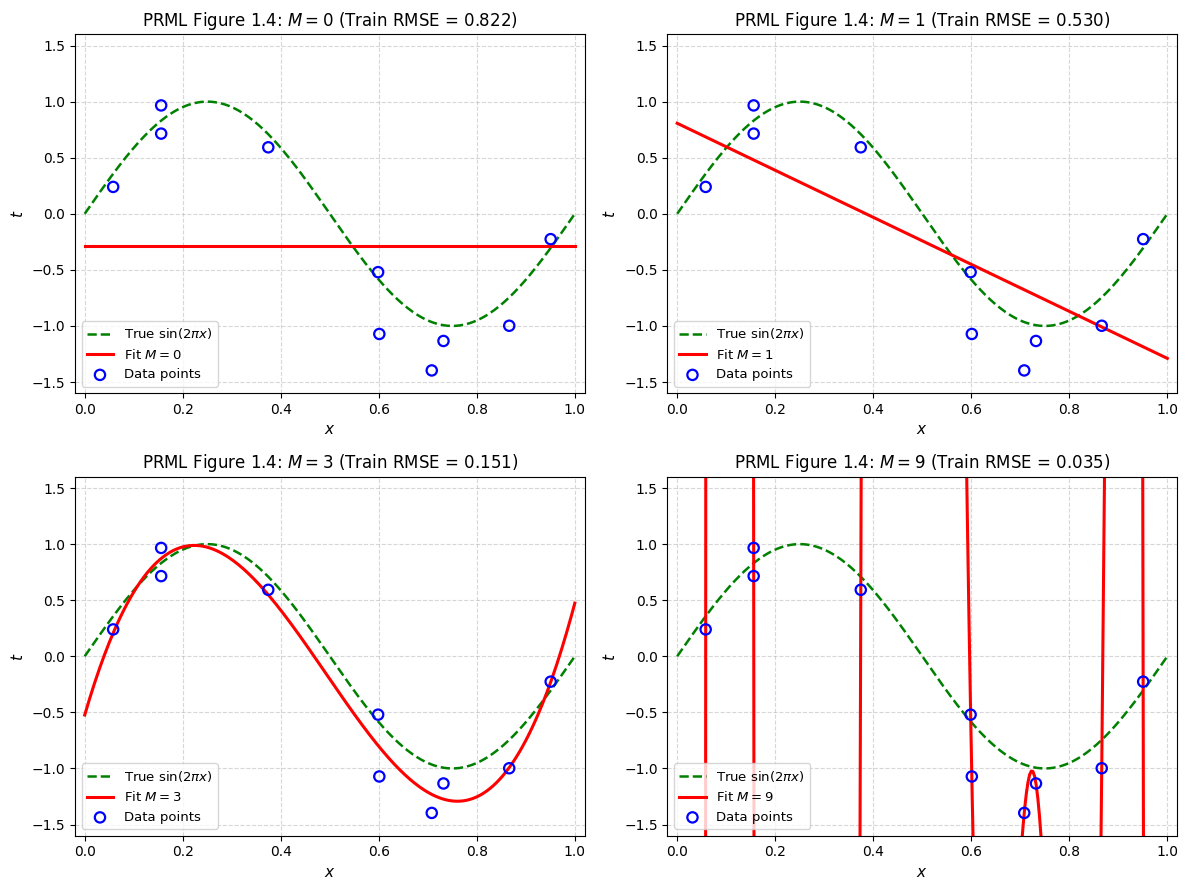

In [2]:
# PRML Figure 1.4 の完全再現: M = 0, 1, 3, 9
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
degrees = [0, 1, 3, 9]

x_dense = np.linspace(0, 1, 300)
t_dense_true = true_function(x_dense)

for ax, M in zip(axes.ravel(), degrees):
    w_star = fit_polynomial_least_squares(x_train, t_train, degree=M)
    Phi_dense = build_design_matrix(x_dense, M)
    y_dense = Phi_dense @ w_star
    
    # 訓練誤差
    Phi_train = build_design_matrix(x_train, M)
    y_train = Phi_train @ w_star
    train_rmse = compute_rms_error(y_train, t_train)
    
    ax.plot(x_dense, t_dense_true, 'g--', lw=1.8, label='True $\\sin(2\\pi x)$')
    ax.plot(x_dense, y_dense, 'r-', lw=2.2, label=f'Fit $M={M}$')
    ax.scatter(x_train, t_train, facecolors='none', edgecolors='b', s=55, lw=1.6, zorder=5, label='Data points')
    
    ax.set_title(f'PRML Figure 1.4: $M = {M}$ (Train RMSE = {train_rmse:.3f})', fontsize=12)
    ax.set_xlabel('$x$', fontsize=11); ax.set_ylabel('$t$', fontsize=11)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-1.6, 1.6)
    ax.legend(loc='lower left', fontsize=9.5)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_4_polynomial_fits.png')
plt.show()

## 1.1.3 二乗平均平方根誤差 (RMS Error) による汎化評価 (PRML Figure 1.5)

訓練セットに対する誤差 $E(\mathbf{w}^*)$ だけでは、モデルの汎化能力を正しく評価できません。
異なるデータサイズ間でも比較できるよう、データ数 $N$ で正規化し目標値 $t$ と同じスケールを持つ**二乗平均平方根誤差（Root-Mean-Square Error, $E_{\text{RMS}}$）**を定義します（PRML 式 1.3）：
$$
E_{\text{RMS}} = \sqrt{\frac{2 E(\mathbf{w}^*)}{N}} = \sqrt{\frac{1}{N} \sum_{n=1}^N \{ y(x_n, \mathbf{w}^*) - t_n \}^2}
$$

$M = 0$ から $M = 9$ までの各多項式について、訓練セット（$N=10$）および独立にサンプリングしたテストセット（$N=100$）に対する $E_{\text{RMS}}$ を計算・比較します。

Plot saved to: result/fig1_5_rms_error.png


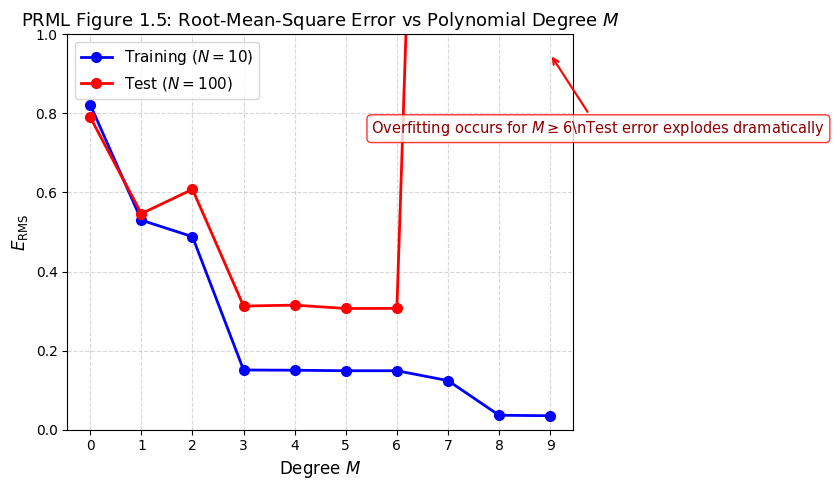

M	Train RMSE	Test RMSE
-----------------------------------
0	0.8219		0.7903
1	0.5299		0.5465
2	0.4883		0.6080
3	0.1511		0.3128
4	0.1505		0.3151
5	0.1492		0.3066
6	0.1492		0.3069
7	0.1243		4.2276
8	0.0366		326.3701
9	0.0353		194.3282


In [3]:
# M in [0, 9] における訓練誤差とテスト誤差の推移
degrees_all = list(range(10))
train_errors = []
test_errors = []

for M in degrees_all:
    w_star = fit_polynomial_least_squares(x_train, t_train, degree=M)
    
    # 訓練RMSE
    Phi_train = build_design_matrix(x_train, M)
    y_train = Phi_train @ w_star
    train_errors.append(compute_rms_error(y_train, t_train))
    
    # テストRMSE
    Phi_test = build_design_matrix(x_test, M)
    y_test = Phi_test @ w_star
    test_errors.append(compute_rms_error(y_test, t_test))

# PRML Figure 1.5 の完全再現
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degrees_all, train_errors, 'b-o', lw=2.0, ms=7, label='Training ($N=10$)')
ax.plot(degrees_all, test_errors, 'r-o', lw=2.0, ms=7, label='Test ($N=100$)')
ax.set_xlabel('Degree $M$', fontsize=12)
ax.set_ylabel('$E_{\\rm RMS}$', fontsize=12)
ax.set_title('PRML Figure 1.5: Root-Mean-Square Error vs Polynomial Degree $M$', fontsize=13)
ax.set_ylim(0.0, 1.0)
ax.set_xticks(degrees_all)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

# 過学習の注釈
ax.annotate('Overfitting occurs for $M \\geq 6$\\nTest error explodes dramatically', 
            xy=(9, test_errors[9] if test_errors[9] < 1.0 else 0.95), 
            xytext=(5.5, 0.75),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
            fontsize=10.5, color='darkred',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))

plt.tight_layout()
save_plot(fig, 'result', 'fig1_5_rms_error.png')
plt.show()

print("M\tTrain RMSE\tTest RMSE")
print("-" * 35)
for M, tr, te in zip(degrees_all, train_errors, test_errors):
    print(f"{M}\t{tr:.4f}\t\t{te:.4f}")

## 1.1.4 重み係数の爆発現象 (PRML Table 1.1 & Figure 1.6)

過学習が起きているとき、内部の重み係数 $\mathbf{w}^*$ に何が起きているのでしょうか？
$M$ が大きくなるにつれて、ヴァンデルモンド行列 $\boldsymbol{\Phi}^T \boldsymbol{\Phi}$ の条件数が悪化し、多項式がデータ点の間で極端に振動するために**正負の巨大な値が激しく打ち消し合う現象**が発生します。

下表とグラフで、各次数における最適係数 $w_j^*$ の大きさを比較します。

=== PRML Table 1.1: Optimal Polynomial Coefficients ===
           M = 0        M = 1        M = 3        M = 9
w_0        -0.28         0.81        -0.52     -1786.68
w_1         0.00        -2.10        15.01     57520.67
w_2         0.00         0.00       -43.46   -609375.98
w_3         0.00         0.00        29.45   2963096.92
w_4         0.00         0.00         0.00  -7472959.29
w_5         0.00         0.00         0.00   9619429.53
w_6         0.00         0.00         0.00  -4291180.44
w_7         0.00         0.00         0.00  -3423031.83
w_8         0.00         0.00         0.00   4661206.68
w_9         0.00         0.00         0.00  -1503271.93


Plot saved to: result/fig1_6_weights_magnitude.png


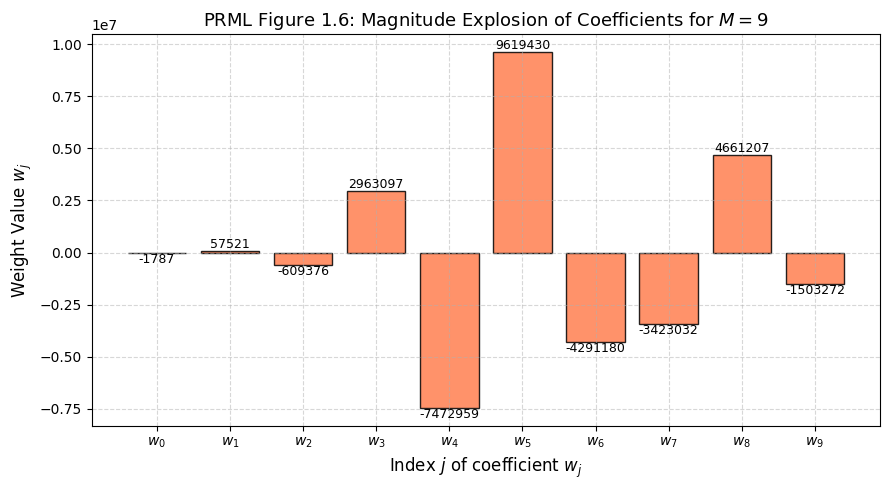

In [4]:
import pandas as pd

# M = 0, 1, 3, 9 の係数を取得
coeff_dict = {}
for M in [0, 1, 3, 9]:
    w_star = fit_polynomial_least_squares(x_train, t_train, degree=M)
    # 9次までゼロ埋め
    w_padded = np.zeros(10)
    w_padded[:M+1] = w_star
    coeff_dict[f'M = {M}'] = w_padded

df_weights = pd.DataFrame(coeff_dict, index=[f'w_{i}' for i in range(10)])
print("=== PRML Table 1.1: Optimal Polynomial Coefficients ===")
print(df_weights.to_string(float_format=lambda x: f"{x:12.2f}"))

# 係数の絶対値の棒グラフ可視化
fig, ax = plt.subplots(figsize=(9, 5))
w9 = coeff_dict['M = 9']
bars = ax.bar(range(10), w9, color='coral', edgecolor='black', alpha=0.85)
ax.set_xlabel('Index $j$ of coefficient $w_j$', fontsize=12)
ax.set_ylabel('Weight Value $w_j$', fontsize=12)
ax.set_title('PRML Figure 1.6: Magnitude Explosion of Coefficients for $M = 9$', fontsize=13)
ax.set_xticks(range(10))
ax.set_xticklabels([f'$w_{{{j}}}$' for j in range(10)])
ax.grid(True, linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    va = 'bottom' if yval >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.0f}', ha='center', va=va, fontsize=9)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_6_weights_magnitude.png')
plt.show()

## 1.1.5 データ数 $N$ による過学習の抑制 (PRML Figure 1.7)

直感に反して、**過学習はモデルのパラメータ数そのものの問題ではなく、データ数に対する相対的な問題**です。
次数 $M=9$ のモデルであっても、訓練データ数を $N=15$ や $N=100$ に増やすと、多項式の自由度に対して十分な制約が与えられ、過学習が著しく緩和されて真の関数 $\sin(2\pi x)$ に高精度に収束していきます。

Plot saved to: result/fig1_7_dataset_size.png


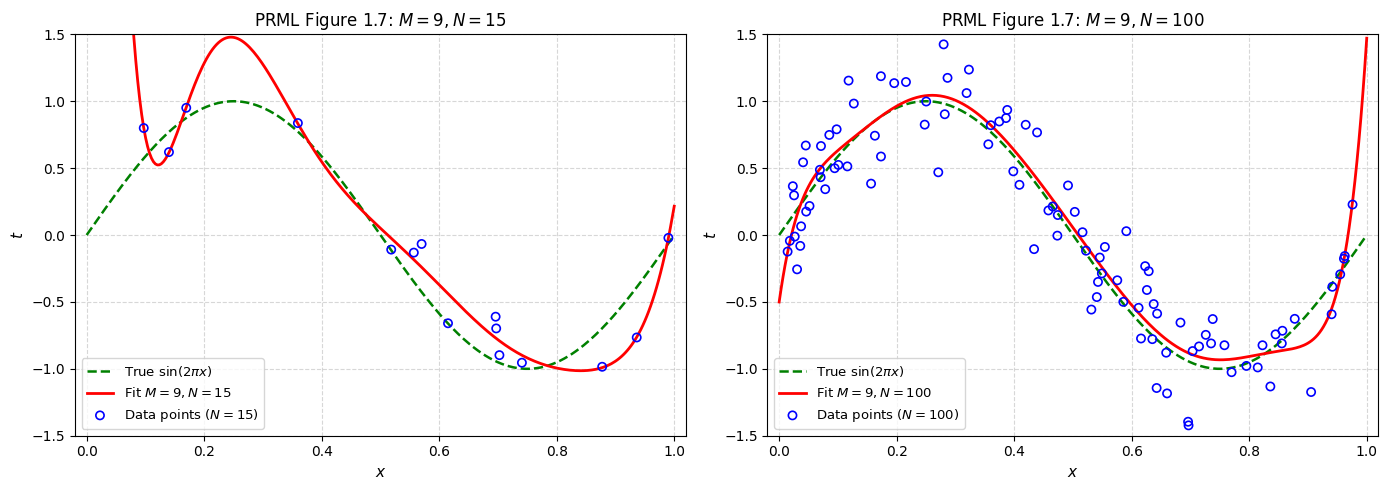

In [5]:
# PRML Figure 1.7 の再現: M = 9 における N = 15 と N = 100 のフィッティング
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, N_data in zip(axes, [15, 100]):
    x_data, t_data = generate_synthetic_data(N_data, noise_std=0.25)
    w_star = fit_polynomial_least_squares(x_data, t_data, degree=9)
    
    Phi_dense = build_design_matrix(x_dense, 9)
    y_dense = Phi_dense @ w_star
    
    ax.plot(x_dense, true_function(x_dense), 'g--', lw=1.8, label='True $\\sin(2\\pi x)$')
    ax.plot(x_dense, y_dense, 'r-', lw=2.0, label=f'Fit $M=9, N={N_data}$')
    ax.scatter(x_data, t_data, facecolors='none', edgecolors='b', s=35, lw=1.2, zorder=5, label=f'Data points ($N={N_data}$)')
    
    ax.set_title(f'PRML Figure 1.7: $M = 9, N = {N_data}$', fontsize=12)
    ax.set_xlabel('$x$', fontsize=11); ax.set_ylabel('$t$', fontsize=11)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-1.5, 1.5)
    ax.legend(loc='lower left', fontsize=9.5)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_7_dataset_size.png')
plt.show()

## 1.1.6 正則化 (Regularization) と Ridge 回帰 (PRML Figure 1.8, 1.9)

データ数が限られている場合、過学習を防ぐ強力な手法が**正則化（Regularization / 重み減衰, Weight Decay）**です。
誤差関数に重み係数の二乗ノルム（$L_2$ ノルム）ペナルティ項を加えます（PRML 式 1.8）：
$$
\widetilde{E}(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \{ y(x_n, \mathbf{w}) - t_n \}^2 + \frac{\lambda}{2} \|\mathbf{w}\|^2
$$
ここで $\|\mathbf{w}\|^2 = \mathbf{w}^T \mathbf{w} = w_0^2 + w_1^2 + \cdots + w_M^2$ であり、$\lambda \ge 0$ は正則化パラメータです（バイアス項 $w_0$ は正則化から除外されることもあります）。

### 正則化された正規方程式
修正された誤差関数 $\widetilde{E}(\mathbf{w})$ を $\mathbf{w}$ で微分して 0 と置くと：
$$
\boldsymbol{\Phi}^T (\boldsymbol{\Phi} \mathbf{w} - \mathbf{t}) + \lambda \mathbf{w} = 0 \implies (\boldsymbol{\Phi}^T \boldsymbol{\Phi} + \lambda \mathbf{I}) \mathbf{w} = \boldsymbol{\Phi}^T \mathbf{t}
$$
したがって、正則化解は：
$$
\mathbf{w}^* = (\boldsymbol{\Phi}^T \boldsymbol{\Phi} + \lambda \mathbf{I})^{-1} \boldsymbol{\Phi}^T \mathbf{t}
$$
$\boldsymbol{\Phi}^T \boldsymbol{\Phi}$ が特異（非正則）であっても、対角に正の $\lambda \mathbf{I}$ が加わることで必ず逆行列が存在し、数値的に極めて安定します。

Plot saved to: result/fig1_8_regularization_fits.png


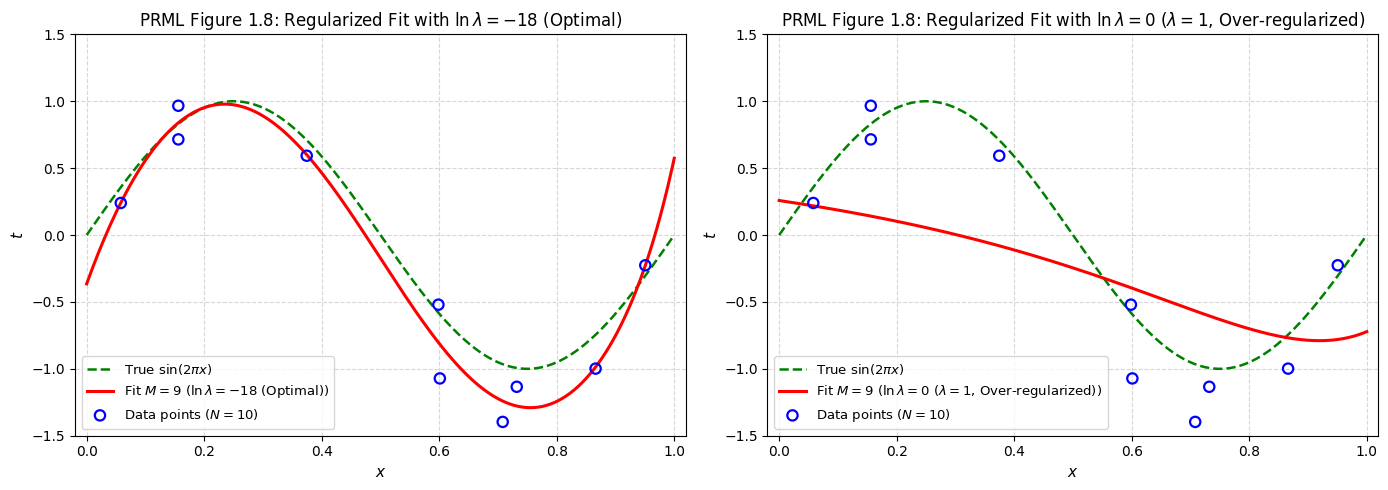

Plot saved to: result/fig1_9_regularization_rms.png


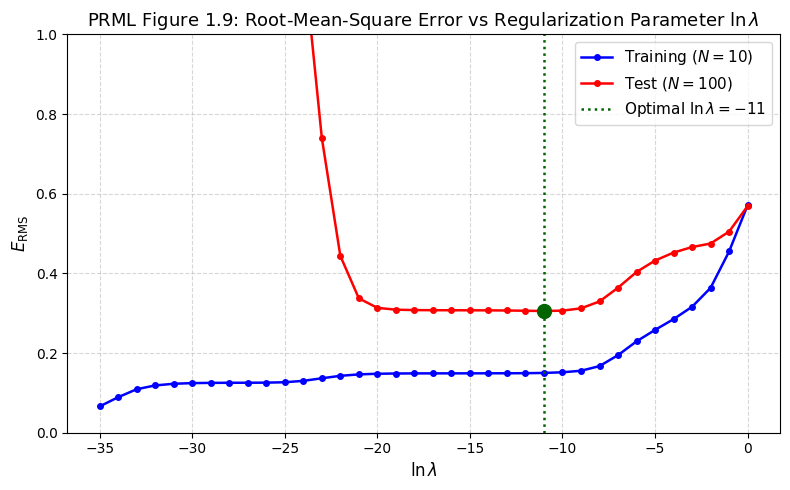

In [6]:
# PRML Figure 1.8: 正則化によるフィッティング曲線の制御 (M = 9, N = 10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lambdas_test = [np.exp(-18), 1.0]
lambda_labels = [r'$\ln \lambda = -18$ (Optimal)', r'$\ln \lambda = 0$ ($\lambda = 1$, Over-regularized)']

for ax, lam, lab in zip(axes, lambdas_test, lambda_labels):
    w_reg = fit_polynomial_least_squares(x_train, t_train, degree=9, lambda_reg=lam)
    Phi_dense = build_design_matrix(x_dense, 9)
    y_reg = Phi_dense @ w_reg
    
    ax.plot(x_dense, true_function(x_dense), 'g--', lw=1.8, label='True $\\sin(2\\pi x)$')
    ax.plot(x_dense, y_reg, 'r-', lw=2.2, label=f'Fit $M=9$ ({lab})')
    ax.scatter(x_train, t_train, facecolors='none', edgecolors='b', s=55, lw=1.6, zorder=5, label='Data points ($N=10$)')
    
    ax.set_title(f'PRML Figure 1.8: Regularized Fit with {lab}', fontsize=12)
    ax.set_xlabel('$x$', fontsize=11); ax.set_ylabel('$t$', fontsize=11)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-1.5, 1.5)
    ax.legend(loc='lower left', fontsize=9.5)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_8_regularization_fits.png')
plt.show()

# PRML Figure 1.9: ln(lambda) に対する E_RMS の推移
ln_lambdas = np.linspace(-35, 0, 36)
train_rms_reg = []
test_rms_reg = []

for ln_lam in ln_lambdas:
    lam = np.exp(ln_lam)
    w_reg = fit_polynomial_least_squares(x_train, t_train, degree=9, lambda_reg=lam)
    
    y_tr = build_design_matrix(x_train, 9) @ w_reg
    y_te = build_design_matrix(x_test, 9) @ w_reg
    
    train_rms_reg.append(compute_rms_error(y_tr, t_train))
    test_rms_reg.append(compute_rms_error(y_te, t_test))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ln_lambdas, train_rms_reg, 'b-o', lw=1.8, ms=4, label='Training ($N=10$)')
ax.plot(ln_lambdas, test_rms_reg, 'r-o', lw=1.8, ms=4, label='Test ($N=100$)')
ax.set_xlabel(r'$\ln \lambda$', fontsize=12)
ax.set_ylabel(r'$E_{\rm RMS}$', fontsize=12)
ax.set_title('PRML Figure 1.9: Root-Mean-Square Error vs Regularization Parameter $\\ln \\lambda$', fontsize=13)
ax.set_ylim(0.0, 1.0)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

best_idx = np.argmin(test_rms_reg)
best_ln_lam = ln_lambdas[best_idx]
ax.axvline(best_ln_lam, color='darkgreen', linestyle=':', lw=1.8, label=f'Optimal $\\ln \\lambda = {best_ln_lam:.0f}$')
ax.scatter([best_ln_lam], [test_rms_reg[best_idx]], color='darkgreen', s=100, zorder=6)
ax.legend(fontsize=11)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_9_regularization_rms.png')
plt.show()

## 1.1.7 L1 正則化 (Lasso) と L2 正則化 (Ridge) の幾何学的比較

PRML第3章（3.1.4節）で詳述される一般化正則化：
$$
\frac{1}{2} \sum_{n=1}^N \{ y(x_n, \mathbf{w}) - t_n \}^2 + \frac{\lambda}{2} \sum_{j=1}^M |w_j|^q
$$
- $q = 2$: **Ridge 回帰 ($L_2$ 正則化)**。制約領域は球体（円）であり、等高線との接点は一般に軸上には来ず、すべての重みが一様に小さくなる。
- $q = 1$: **Lasso 回帰 ($L_1$ 正則化)**。制約領域は菱形（角錐）であり、等高線が角（軸上）で接しやすいため、**不要な係数が厳密にゼロになる（スパース性, Sparsity）**。

Plot saved to: result/fig1_l1_vs_l2_geometry.png


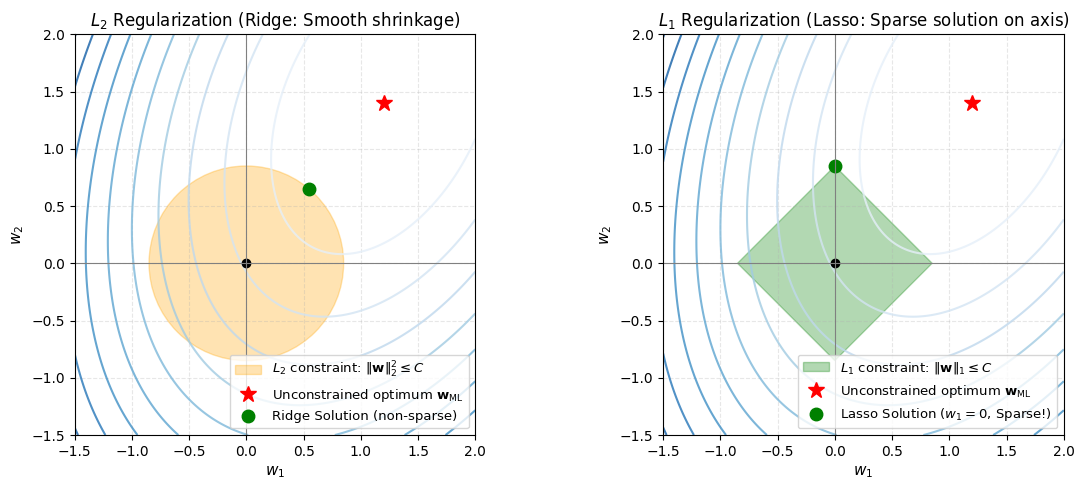

In [7]:
# L1 vs L2 正則化領域と等高線の幾何学的可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 2変数の損失関数等高線 (仮想の最小二乗中心 w_hat = [1.2, 1.4])
w1 = np.linspace(-1.5, 2.0, 300)
w2 = np.linspace(-1.5, 2.0, 300)
W1, W2 = np.meshgrid(w1, w2)
# 楕円形の等高線
Z_loss = 1.8 * (W1 - 1.2)**2 + 1.0 * (W2 - 1.4)**2 - 1.0 * (W1 - 1.2) * (W2 - 1.4)

# 1. L2 正則化 (円: w1^2 + w2^2 <= r^2)
ax1.contour(W1, W2, Z_loss, levels=12, cmap='Blues', alpha=0.8)
circle = plt.Circle((0, 0), 0.85, color='orange', alpha=0.3, label=r'$L_2$ constraint: $\|\mathbf{w}\|_2^2 \leq C$')
ax1.add_patch(circle)
ax1.plot(0, 0, 'ko', ms=6)
ax1.plot(1.2, 1.4, 'r*', ms=12, label=r'Unconstrained optimum $\mathbf{w}_{\rm ML}$')
# 接点 (非ゼロ)
ax1.plot(0.55, 0.65, 'go', ms=9, label='Ridge Solution (non-sparse)')
ax1.set_xlim(-1.5, 2.0); ax1.set_ylim(-1.5, 2.0)
ax1.set_xlabel('$w_1$', fontsize=11); ax1.set_ylabel('$w_2$', fontsize=11)
ax1.set_title(r'$L_2$ Regularization (Ridge: Smooth shrinkage)', fontsize=12)
ax1.axhline(0, color='gray', lw=0.8); ax1.axvline(0, color='gray', lw=0.8)
ax1.legend(loc='lower right', fontsize=9.5)
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', alpha=0.3)

# 2. L1 正則化 (菱形: |w1| + |w2| <= r)
ax2.contour(W1, W2, Z_loss, levels=12, cmap='Blues', alpha=0.8)
diamond = plt.Polygon([[0.85, 0], [0, 0.85], [-0.85, 0], [0, -0.85]], color='green', alpha=0.3, label=r'$L_1$ constraint: $\|\mathbf{w}\|_1 \leq C$')
ax2.add_patch(diamond)
ax2.plot(0, 0, 'ko', ms=6)
ax2.plot(1.2, 1.4, 'r*', ms=12, label=r'Unconstrained optimum $\mathbf{w}_{\rm ML}$')
# 接点が軸上 (w1 = 0)
ax2.plot(0.0, 0.85, 'go', ms=9, label='Lasso Solution ($w_1 = 0$, Sparse!)')
ax2.set_xlim(-1.5, 2.0); ax2.set_ylim(-1.5, 2.0)
ax2.set_xlabel('$w_1$', fontsize=11); ax2.set_ylabel('$w_2$', fontsize=11)
ax2.set_title(r'$L_1$ Regularization (Lasso: Sparse solution on axis)', fontsize=12)
ax2.axhline(0, color='gray', lw=0.8); ax2.axvline(0, color='gray', lw=0.8)
ax2.legend(loc='lower right', fontsize=9.5)
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_l1_vs_l2_geometry.png')
plt.show()

## まとめ

本節では、多項式曲線フィッティングを通じて機械学習の根幹をなす理論的諸性質を解き明かしました：

1. **正規方程式の解法**: 二乗和誤差最小化問題は、線形モデルにおいては解析的行列逆演算 $\mathbf{w}^* = (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^T\mathbf{t}$ で厳密に解ける。
2. **モデル次数と表現力**: $M$ が小さければ未学習（高バイアス）、$M$ が大きすぎればデータ点間での激しい発散（過学習・高バリアンス）が生じる。
3. **データ数 $N$ の重要性**: 過学習はモデルのパラメータ数とデータ数 $N$ の相対比で決まり、データ数を増大させることで過学習は劇的に緩和される。
4. **正則化**: 誤差関数にパラメータのノルムペナルティを加えることで、複雑なモデルの表現力を維持しつつ極端な重みの振動を抑え、最良の汎化性能を達成できる。
5. **ベイズ的視点への展開**: 次節 1.2 節では、この二乗和誤差最小化が**ガウスノイズのもとでの最尤推定**と厳密に等価であり、正則化が**ガウス事前分布のもとでのMAP推定**に対応することを明らかにします。